In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kagglehub as kh
import os
import keras

from sklearn.preprocessing import MinMaxScaler
from helper import *
from keras.layers import LSTM, Dense, RepeatVector, TimeDistributed, Input, BatchNormalization

In [2]:
training = False

In [3]:
tf.random.set_seed(42)

In [4]:
path = kh.dataset_download("palbha/cmapss-jet-engine-simulated-data")

In [5]:
col_names = ['Unit', 'Cycle Time'] + [f'Sensor {_+1}' for _ in range(26)]
df = pd.read_csv(os.path.join(path, 'train_FD001.txt'), sep=' ', header=None, names=col_names)
df_test = pd.read_csv(os.path.join(path, 'test_FD001.txt'), sep=' ', header=None, names=col_names)

In [6]:
df.head()

,Unit,Cycle Time,Sensor 1,Sensor 2,Sensor 3,Sensor 4,Sensor 5,Sensor 6,Sensor 7,Sensor 8,...,Sensor 17,Sensor 18,Sensor 19,Sensor 20,Sensor 21,Sensor 22,Sensor 23,Sensor 24,Sensor 25,Sensor 26
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,NaN,NaN
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,NaN,NaN
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,NaN,NaN
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,NaN,NaN
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,NaN,NaN


In [7]:
# Using to_string with specific formatting
with open('data_summary_FD001.txt', 'w') as f:
    f.write("CMAPSS Dataset Summary Statistics\n")
    f.write("="*30 + "\n")
    f.write(df.describe().transpose().to_string()) # Transpose makes it easier to read if you have many sensors

In [8]:
cols_to_drop = ['Sensor 3', 'Sensor 21', 'Sensor 22', 'Sensor 25', 'Sensor 26']
relevant_sensors = [f'Sensor {_+1}' for _ in range(26) if _ not in (2, 20, 21, 24, 25)]
df = df.drop(columns=cols_to_drop)
df_test = df_test.drop(columns=cols_to_drop)
df.head()

,Unit,Cycle Time,Sensor 1,Sensor 2,Sensor 4,Sensor 5,Sensor 6,Sensor 7,Sensor 8,Sensor 9,...,Sensor 13,Sensor 14,Sensor 15,Sensor 16,Sensor 17,Sensor 18,Sensor 19,Sensor 20,Sensor 23,Sensor 24
0,1,1,-0.0007,-0.0004,518.67,641.82,1589.70,1400.60,14.62,21.61,...,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,39.06,23.4190
1,1,2,0.0019,-0.0003,518.67,642.15,1591.82,1403.14,14.62,21.61,...,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,39.00,23.4236
2,1,3,-0.0043,0.0003,518.67,642.35,1587.99,1404.20,14.62,21.61,...,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,38.95,23.3442
3,1,4,0.0007,0.0000,518.67,642.35,1582.79,1401.87,14.62,21.61,...,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,38.88,23.3739
4,1,5,-0.0019,-0.0002,518.67,642.37,1582.85,1406.22,14.62,21.61,...,1.3,47.28,522.19,2388.04,8133.80,8.4294,0.03,393,38.90,23.4044


In [9]:
print(relevant_sensors)

['Sensor 1', 'Sensor 2', 'Sensor 4', 'Sensor 5', 'Sensor 6', 'Sensor 7', 'Sensor 8', 'Sensor 9', 'Sensor 10', 'Sensor 11', 'Sensor 12', 'Sensor 13', 'Sensor 14', 'Sensor 15', 'Sensor 16', 'Sensor 17', 'Sensor 18', 'Sensor 19', 'Sensor 20', 'Sensor 23', 'Sensor 24']


In [10]:
scaler = MinMaxScaler()
df[relevant_sensors] = scaler.fit_transform(df[relevant_sensors])
df_test[relevant_sensors] = scaler.transform(df_test[relevant_sensors])

df = df[['Unit', 'Cycle Time'] + relevant_sensors]
df_test = df_test[['Unit', 'Cycle Time'] + relevant_sensors]
df.head()

,Unit,Cycle Time,Sensor 1,Sensor 2,Sensor 4,Sensor 5,Sensor 6,Sensor 7,Sensor 8,Sensor 9,...,Sensor 13,Sensor 14,Sensor 15,Sensor 16,Sensor 17,Sensor 18,Sensor 19,Sensor 20,Sensor 23,Sensor 24
0,1,1,0.459770,0.166667,0.0,0.183735,0.406802,0.309757,0.0,1.0,...,0.0,0.369048,0.633262,0.205882,0.199608,0.363986,0.0,0.333333,0.713178,0.724662
1,1,2,0.609195,0.250000,0.0,0.283133,0.453019,0.352633,0.0,1.0,...,0.0,0.380952,0.765458,0.279412,0.162813,0.411312,0.0,0.333333,0.666667,0.731014
2,1,3,0.252874,0.750000,0.0,0.343373,0.369523,0.370527,0.0,1.0,...,0.0,0.250000,0.795309,0.220588,0.171793,0.357445,0.0,0.166667,0.627907,0.621375
3,1,4,0.540230,0.500000,0.0,0.343373,0.256159,0.331195,0.0,1.0,...,0.0,0.166667,0.889126,0.294118,0.174889,0.166603,0.0,0.333333,0.573643,0.662386
4,1,5,0.390805,0.333333,0.0,0.349398,0.257467,0.404625,0.0,1.0,...,0.0,0.255952,0.746269,0.235294,0.174734,0.402078,0.0,0.416667,0.589147,0.704502


In [11]:
wsize = 30

def gen_train_windows(df, window_size):
    X = []
    for unit in df['Unit'].unique():
        unit_data = df[df['Unit'] == unit][relevant_sensors].values
        # Only take the beginning of each engine's life for 'Healthy' baseline
        healthy_data = unit_data[:50] 
        if len(healthy_data) >= window_size:
            for i in range(len(healthy_data) - window_size + 1):
                X.append(healthy_data[i:i+window_size])
    return np.array(X)

X_train = gen_train_windows(df, wsize)

In [12]:
def gen_test_windows(df, window_size):
    X = []
    unit_ids = []
    for unit in df['Unit'].unique():
        unit_data = df[df['Unit'] == unit][relevant_sensors].values
        if len(unit_data) >= window_size:
            # Take the LAST window of the test engine to check its current health
            X.append(unit_data[-window_size:])
            unit_ids.append(unit)
    return np.array(X), unit_ids

X_test, test_units = gen_test_windows(df_test, wsize)

In [13]:
print(X_train.shape)
print(X_test.shape)

(2100, 30, 21)
(100, 30, 21)


In [14]:
model = tf.keras.models.Sequential([
    Input(shape=(wsize, len(relevant_sensors))),
    LSTM(64, activation='relu', return_sequences=False),
    RepeatVector(wsize),
    LSTM(64, activation='relu', return_sequences=True),
    TimeDistributed(Dense(len(relevant_sensors)))
])

In [15]:
model.compile(optimizer='adam', loss='mae')

In [ ]:
callbacks = [keras.callbacks.EarlyStopping(monitor='val_loss', patience=5),
             keras.callbacks.ModelCheckpoint(filepath='best_model_fd001.keras', monitor='val_loss', save_best_only=True)]

if training:
    history = model.fit(
        X_train, X_train, 
        epochs=50, 
        batch_size=32, 
        validation_split=0.1, 
        verbose=1,
        callbacks=callbacks
    )

In [ ]:
model = keras.models.load_model('best_model_fd001.keras')

In [18]:
X_train_pred = model.predict(X_train)
train_mae_loss = np.mean(np.abs(X_train_pred - X_train), axis=(1, 2))

# Set the threshold: Anything 3 standard deviations above the mean error is a "Failure"
threshold = np.mean(train_mae_loss) + (3 * np.std(train_mae_loss))

print(f"Quiet Failure Threshold: {threshold}")

66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Quiet Failure Threshold: 0.06106859686914297


In [19]:
X_test_pred = model.predict(X_test)
test_mae_loss = np.mean(np.abs(X_test_pred - X_test), axis=(1, 2))

# Identify which units have crossed the threshold
is_failing = test_mae_loss > threshold

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [20]:
print(is_failing)

[False False False False False False False False False False False False
 False False False False False False False  True False False False  True
 False False False False False False  True  True False  True  True  True
 False False False False False  True False False False False False False
  True False False  True  True False False  True False False False False
 False  True False False  True  True False  True False False False False
 False False False  True False False False False  True  True False False
 False False False False False  True  True  True False False False False
 False False False  True]


In [21]:
def get_engine_history(df, unit_id, window_size, feature_cols):
    # 1. Isolate just one engine's data
    unit_data = df[df['Unit'] == unit_id][feature_cols].values
    
    # 2. Create sliding windows (X_test_full_sequence)
    # This preserves the time-order of the engine
    X_sequence = []
    for i in range(len(unit_data) - window_size + 1):
        X_sequence.append(unit_data[i:i + window_size])
        
    return np.array(X_sequence)


In [22]:
X_test_full_sequence = get_engine_history(df_test, unit_id=3, window_size=30, feature_cols=relevant_sensors)

# 1. Predict on a full engine's history
engine_data = X_test_full_sequence # Sequences for a single engine
reconstructed = model.predict(engine_data)

# 2. Calculate the 'Anomaly Score' (MAE per cycle)
# We average across both the window (30) and the sensors (21)
anomaly_score = np.mean(np.abs(engine_data - reconstructed), axis=(1, 2))

# 3. Detect the moment of Quiet Failure
try:
    alert_cycle = np.where(anomaly_score > threshold)[0][0]
    print(f"Quiet Failure detected at Cycle: {alert_cycle}")
except IndexError:
    print('No Failure!')

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
No Failure!


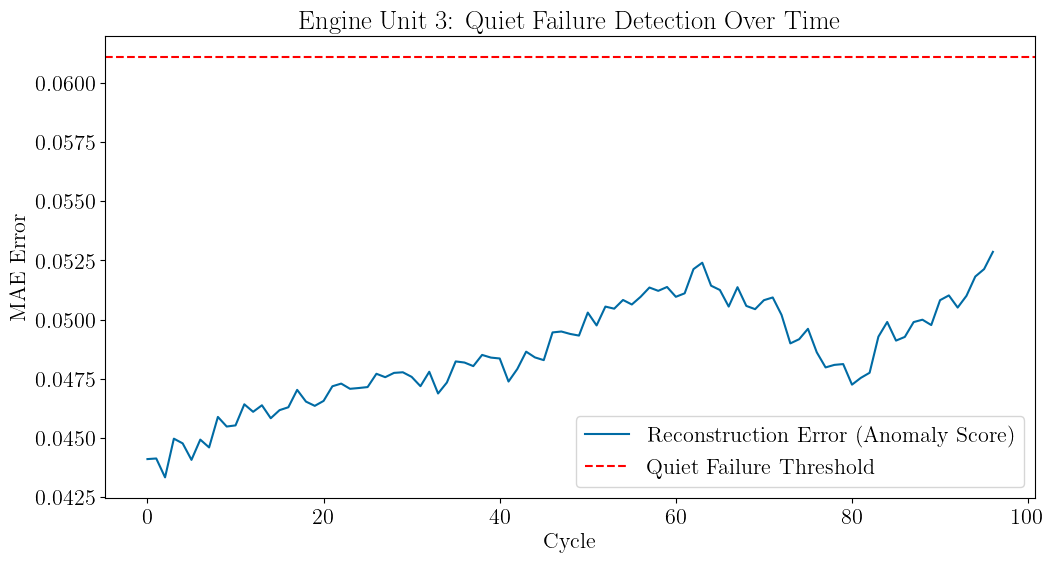

In [ ]:
fig = failure_plot(anomaly_score, threshold, unit_no=3)
fig.show()

In [24]:
X_test_full_sequence = get_engine_history(df_test, unit_id=17, window_size=30, feature_cols=relevant_sensors)

# 1. Predict on a full engine's history
engine_data = X_test_full_sequence # Sequences for a single engine
reconstructed = model.predict(engine_data)

# 2. Calculate the 'Anomaly Score' (MAE per cycle)
# We average across both the window (30) and the sensors (21)
anomaly_score = np.mean(np.abs(engine_data - reconstructed), axis=(1, 2))

# 3. Detect the moment of Quiet Failure
try:
    alert_cycle = np.where(anomaly_score > threshold)[0][0]
    print(f"Quiet Failure detected at Cycle: {alert_cycle}")
except IndexError:
    print('No Failure!')

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
No Failure!


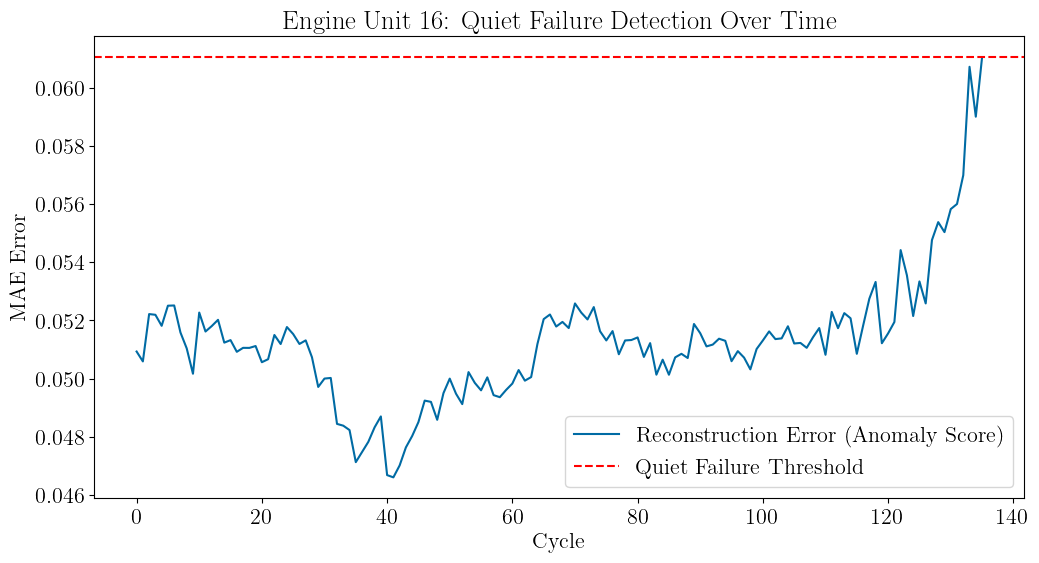

In [ ]:
fig = failure_plot(anomaly_score, threshold, unit_no=16)
fig.show()

In [26]:
col_names = ['Unit', 'Cycle Time'] + [f'Sensor {_+1}' for _ in range(26)]
df = pd.read_csv(os.path.join(path, 'train_FD004.txt'), sep=' ', header=None, names=col_names)
df_test = pd.read_csv(os.path.join(path, 'test_FD004.txt'), sep=' ', header=None, names=col_names)

In [27]:
df.head()

,Unit,Cycle Time,Sensor 1,Sensor 2,Sensor 3,Sensor 4,Sensor 5,Sensor 6,Sensor 7,Sensor 8,...,Sensor 17,Sensor 18,Sensor 19,Sensor 20,Sensor 21,Sensor 22,Sensor 23,Sensor 24,Sensor 25,Sensor 26
0,1,1,42.0049,0.8400,100.0,445.00,549.68,1343.43,1112.93,3.91,...,8074.83,9.3335,0.02,330,2212,100.00,10.62,6.3670,NaN,NaN
1,1,2,20.0020,0.7002,100.0,491.19,606.07,1477.61,1237.50,9.35,...,8046.13,9.1913,0.02,361,2324,100.00,24.37,14.6552,NaN,NaN
2,1,3,42.0038,0.8409,100.0,445.00,548.95,1343.12,1117.05,3.91,...,8066.62,9.4007,0.02,329,2212,100.00,10.48,6.4213,NaN,NaN
3,1,4,42.0000,0.8400,100.0,445.00,548.70,1341.24,1118.03,3.91,...,8076.05,9.3369,0.02,328,2212,100.00,10.54,6.4176,NaN,NaN
4,1,5,25.0063,0.6207,60.0,462.54,536.10,1255.23,1033.59,7.05,...,7865.80,10.8366,0.02,305,1915,84.93,14.03,8.6754,NaN,NaN


In [28]:
# Using to_string with specific formatting
with open('data_summary_FD004.txt', 'w') as f:
    f.write("CMAPSS Dataset Summary Statistics\n")
    f.write("="*30 + "\n")
    f.write(df.describe().transpose().to_string()) # Transpose makes it easier to read if you have many sensors

In [29]:
cols_to_drop = ['Sensor 25', 'Sensor 26']
relevant_sensors = [f'Sensor {_+1}' for _ in range(24)]
df = df.drop(columns=cols_to_drop)
df_test = df_test.drop(columns=cols_to_drop)
df.head()

,Unit,Cycle Time,Sensor 1,Sensor 2,Sensor 3,Sensor 4,Sensor 5,Sensor 6,Sensor 7,Sensor 8,...,Sensor 15,Sensor 16,Sensor 17,Sensor 18,Sensor 19,Sensor 20,Sensor 21,Sensor 22,Sensor 23,Sensor 24
0,1,1,42.0049,0.8400,100.0,445.00,549.68,1343.43,1112.93,3.91,...,129.78,2387.99,8074.83,9.3335,0.02,330,2212,100.00,10.62,6.3670
1,1,2,20.0020,0.7002,100.0,491.19,606.07,1477.61,1237.50,9.35,...,312.59,2387.73,8046.13,9.1913,0.02,361,2324,100.00,24.37,14.6552
2,1,3,42.0038,0.8409,100.0,445.00,548.95,1343.12,1117.05,3.91,...,129.62,2387.97,8066.62,9.4007,0.02,329,2212,100.00,10.48,6.4213
3,1,4,42.0000,0.8400,100.0,445.00,548.70,1341.24,1118.03,3.91,...,129.80,2388.02,8076.05,9.3369,0.02,328,2212,100.00,10.54,6.4176
4,1,5,25.0063,0.6207,60.0,462.54,536.10,1255.23,1033.59,7.05,...,164.11,2028.08,7865.80,10.8366,0.02,305,1915,84.93,14.03,8.6754


In [30]:
df[relevant_sensors] = df[relevant_sensors].astype('float64')
df_test[relevant_sensors] = df_test[relevant_sensors].astype('float64')

In [31]:
def scale_by_unit(df, features):
    df_scaled = df.copy()
    # We use a single scaler object but apply it unit by unit
    # Or better: we use Global Scaling AFTER removing the unit-specific bias
    for unit in df['Unit'].unique():
        unit_idx = df[df['Unit'] == unit].index
        # Get data for this unit
        unit_data = df.loc[unit_idx, features]
        
        # Fit a scaler on JUST this unit's early life (first 30 cycles)
        # This defines what "Healthy" looks like for THIS specific engine environment
        unit_scaler = MinMaxScaler()
        unit_scaler.fit(unit_data.iloc[:30]) 
        
        # Transform the entire life of this unit
        df_scaled.loc[unit_idx, features] = unit_scaler.transform(unit_data)
        
    return df_scaled

In [32]:
df = scale_by_unit(df, relevant_sensors)
df_test = scale_by_unit(df_test, relevant_sensors)

# Now your data is ready for gen_train_windows
X_train = gen_train_windows(df, wsize)

In [33]:
model = tf.keras.models.Sequential([
    Input(shape=(wsize, len(relevant_sensors))),
    LSTM(64, activation='relu', return_sequences=False),
    RepeatVector(wsize),
    LSTM(64, activation='relu', return_sequences=True),
    TimeDistributed(Dense(len(relevant_sensors)))
])


opt = tf.keras.optimizers.Adam(learning_rate=5e-4, clipnorm=1.0)
model.compile(optimizer=opt, loss='mse', metrics=['mae',]) # Switch to MSE

In [34]:
callbacks = [
    # Give the LR reducer a chance to work BEFORE early stopping kicks in
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-7, verbose=1),
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    keras.callbacks.ModelCheckpoint(filepath='best_model_fd004.keras', monitor='val_loss', save_best_only=True)
]

if True:
    history = model.fit(
        X_train, X_train, 
        epochs=50, 
        batch_size=128, 
        validation_split=0.1, 
        verbose=1,
        callbacks=callbacks
    )

Epoch 1/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.3460 - mae: 0.4766 - val_loss: 0.1638 - val_mae: 0.3323 - learning_rate: 5.0000e-04
Epoch 2/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.1463 - mae: 0.3139 - val_loss: 0.1265 - val_mae: 0.2919 - learning_rate: 5.0000e-04
Epoch 3/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.1221 - mae: 0.2868 - val_loss: 0.1198 - val_mae: 0.2844 - learning_rate: 5.0000e-04
Epoch 4/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.1167 - mae: 0.2808 - val_loss: 0.1167 - val_mae: 0.2808 - learning_rate: 5.0000e-04
Epoch 5/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.1145 - mae: 0.2789 - val_loss: 0.1156 - val_mae: 0.2794 - learning_rate: 5.0000e-04
Epoch 6/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.1135 - mae: 0.2775 - val_loss: 0.1151 - val_mae: 0.2798 - learning_rate: 5.0000e-04
Epoch 7/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 0.1131 - mae: 0.2770 - val_loss: 0.1147 - val_mae: 0.2778 - learning_ra

In [35]:
model = keras.models.load_model('best_model_fd004.keras')

In [36]:
# Predict on healthy training data
X_train_pred = model.predict(X_train)

# Calculate MAE for each window
train_mae_loss = np.mean(np.abs(X_train_pred - X_train), axis=(1, 2))

# Set a stricter threshold for the noisy FD004 environment
# Sometimes 3.5 or 4 standard deviations is safer to avoid false alarms
threshold_fd004 = np.mean(train_mae_loss) + (3 * np.std(train_mae_loss))

print(f"New FD004 Threshold: {threshold_fd004}")

164/164 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
New FD004 Threshold: 0.33848234257822546


In [37]:
X_test, test_units = gen_test_windows(df_test, wsize)
X_test_pred = model.predict(X_test)
test_mae_loss = np.mean(np.abs(X_test_pred - X_test), axis=(1, 2))

# Identify which units have crossed the threshold
is_failing = test_mae_loss > threshold

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [38]:
print(is_failing)

[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  T